In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
X = X.ravel()
y = y.ravel()

In [3]:
b, m = 150, -127.82  # Starting way off in the corner of the map
lr, epochs = 0.001, 30
all_b, all_m = [b], [m]

for i in range(epochs):
    error = y - (m * X) - b
    b = b - (lr * -2 * np.sum(error))
    m = m - (lr * -2 * np.sum(error * X))
    all_b.append(b)
    all_m.append(m)

In [4]:
print("Calculating the 3D Bowl shape...")
m_arr = np.linspace(-150, 150, 50)
b_arr = np.linspace(-150, 150, 50)
M, B = np.meshgrid(m_arr, b_arr)
Z = np.zeros_like(M)

# Calculate the error for every single pixel on the map
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = np.sum((y - (M[i, j] * X) - B[i, j])**2)

Calculating the 3D Bowl shape...


Rendering animation...
Done! Saved as contour_gradient_descent.gif


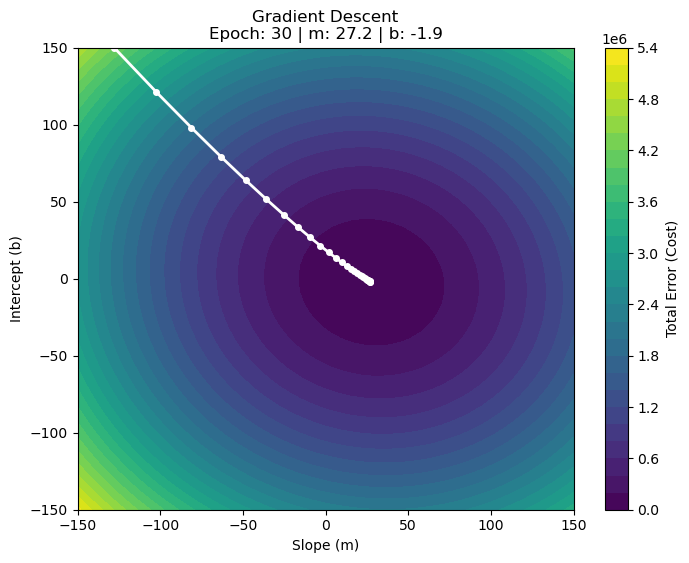

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the background rings (cmap='viridis' gives it that cool purple-to-yellow look)
cp = ax.contourf(M, B, Z, levels=30, cmap='viridis')
fig.colorbar(cp, label="Total Error (Cost)")

ax.set_xlabel("Slope (m)")
ax.set_ylabel("Intercept (b)")

# Setup the white line that will trace the path
line, = ax.plot([], [], color='white', lw=2, marker='o', markersize=4)

def animate(i):
    # Update the line to show the path up to the current epoch
    line.set_data(all_m[:i+1], all_b[:i+1])
    ax.set_title(f"Gradient Descent\nEpoch: {i} | m: {all_m[i]:.1f} | b: {all_b[i]:.1f}")
    return line,

# Render and save
print("Rendering animation...")
anim = FuncAnimation(fig, animate, frames=epochs+1, interval=200, blit=True)
anim.save("contour_gradient_descent.gif", writer=PillowWriter(fps=5))
print("Done! Saved as contour_gradient_descent.gif")